# RQ7: Multi-Class Classification — Can ML Predict Developer Role?

**Research Question:** Can machine learning classifiers accurately infer a developer's individual contributor vs. people manager status, or their primary development role category, from their technology stack, work patterns, and experience profile — and which features most discriminate between role categories?

**Task:** Multi-Class Classification (two targets)  
**Target A:** `ICorPM` (binary: IC vs Manager)  
**Target B:** `DevType` simplified to 8 role groups  
**Models:** Logistic Regression (multinomial), Random Forest, LightGBM  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [1]:
!pip install lightgbm --quiet

In [2]:
import os
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#795548', '#607D8B']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

def multihot_encode(series, top_n=15, prefix=''):
    all_vals = []
    for v in series.dropna():
        if v != 'NA':
            all_vals.extend([x.strip() for x in v.split(';')])
    top_vals = [v for v, _ in Counter(all_vals).most_common(top_n)]
    result = pd.DataFrame(index=series.index)
    for val in top_vals:
        col = f"{prefix}{val.replace(' ', '_').replace(',', '').replace('/', '_')}"
        result[col] = series.apply(
            lambda x: 1 if (isinstance(x, str) and x != 'NA' and val in x.split(';')) else 0
        )
    return result, top_vals

ORGSIZE_MAP = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 2, '20 to 99 employees': 3,
    '100 to 499 employees': 4, '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6, '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8
}

DEVTYPE_GROUP_MAP = {
    'Developer, full-stack':                         'Full-Stack',
    'Developer, back-end':                           'Backend',
    'Developer, front-end':                          'Frontend',
    'Developer, mobile':                             'Mobile',
    'Developer, embedded applications or devices':   'Embedded',
    'Data scientist':                                'Data/AI',
    'AI/ML engineer':                                'Data/AI',
    'Data engineer':                                 'Data/AI',
    'DevOps engineer or professional':               'DevOps',
    'Architect, software or solutions':              'Architect'
}

def devtype_first_match(devtype_str):
    if not isinstance(devtype_str, str) or devtype_str == 'NA':
        return None
    for role in devtype_str.split(';'):
        role = role.strip()
        if role in DEVTYPE_GROUP_MAP:
            return DEVTYPE_GROUP_MAP[role]
    return None

print('Imports OK')

Imports OK


## 1. Data Loading

In [3]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)


## 2. Feature Engineering

In [4]:
df['YearsCode']   = pd.to_numeric(df['YearsCode'], errors='coerce')
df['WorkExp']     = pd.to_numeric(df['WorkExp'],   errors='coerce')
df['OrgSize_num'] = df['OrgSize'].map(ORGSIZE_MAP)

# Multi-hot: top 15 languages
lang_mh,  _ = multihot_encode(df['LanguageHaveWorkedWith'],  top_n=15, prefix='lang_')
# Multi-hot: top 10 web frameworks
wf_mh,    _ = multihot_encode(df['WebframeHaveWorkedWith'],  top_n=10, prefix='wf_')
# Multi-hot: top 10 databases
db_mh,    _ = multihot_encode(df['DatabaseHaveWorkedWith'],  top_n=10, prefix='db_')

df = pd.concat([df.reset_index(drop=True),
                lang_mh.reset_index(drop=True),
                wf_mh.reset_index(drop=True),
                db_mh.reset_index(drop=True)], axis=1)

LANG_COLS = list(lang_mh.columns)
WF_COLS   = list(wf_mh.columns)
DB_COLS   = list(db_mh.columns)

NUMERIC_FEATURES = ['YearsCode', 'WorkExp', 'OrgSize_num'] + LANG_COLS + WF_COLS + DB_COLS
CAT_FEATURES     = ['RemoteWork', 'EdLevel']

for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown')

# Target A: ICorPM binary
df['ICorPM_binary'] = df['ICorPM'].apply(
    lambda x: 1 if x == 'People manager' else
              (0 if x == 'Individual contributor' else np.nan)
)

# Target B: DevType group
df['DevType_Group'] = df['DevType'].apply(devtype_first_match)

print(f'ICorPM binary non-NA: {df["ICorPM_binary"].notna().sum()}')
print(f'DevType Group non-None:', df['DevType_Group'].value_counts().head(10))

ICorPM binary non-NA: 33211
DevType Group non-None: DevType_Group
Full-Stack    12339
Backend        6446
Architect      2680
Data/AI        2019
Frontend       1972
Mobile         1389
Embedded       1273
DevOps         1053
Name: count, dtype: int64


## 3. Exploratory Data Analysis

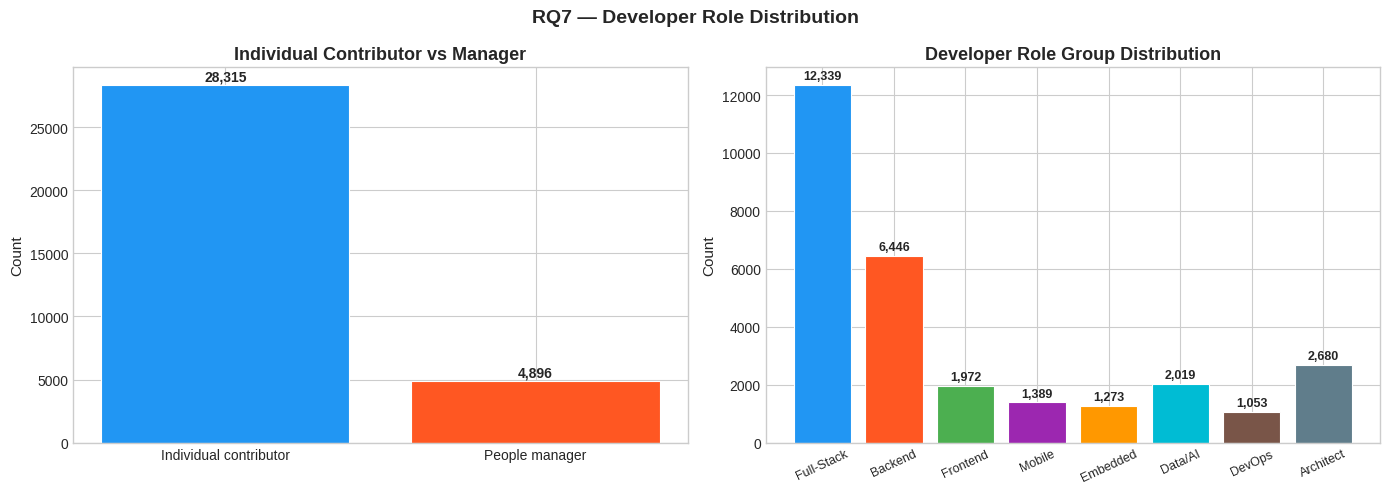

Saved figure: /kaggle/working/rq7_role_distribution.pdf


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ICorPM distribution
icpm_counts = df['ICorPM'].value_counts().head(5)
axes[0].bar(icpm_counts.index, icpm_counts.values, color=PALETTE[:len(icpm_counts)],
            edgecolor='white', linewidth=0.8)
for i, (val, cnt) in enumerate(icpm_counts.items()):
    axes[0].text(i, cnt + 100, f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Individual Contributor vs Manager', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', labelsize=10)

# DevType Group distribution
dt_counts = df['DevType_Group'].value_counts()
DEVTYPE_ORDER = ['Full-Stack', 'Backend', 'Frontend', 'Mobile', 'Embedded', 'Data/AI', 'DevOps', 'Architect']
dt_plot = dt_counts.reindex([g for g in DEVTYPE_ORDER if g in dt_counts.index]).dropna()
axes[1].bar(dt_plot.index, dt_plot.values, color=PALETTE[:len(dt_plot)], edgecolor='white', linewidth=0.8)
for i, cnt in enumerate(dt_plot.values):
    axes[1].text(i, cnt + 100, f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Developer Role Group Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', labelsize=9, rotation=25)

fig.suptitle('RQ7 — Developer Role Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq7_role_distribution.pdf')
plt.show()

## 4. Preprocessing Pipeline

In [6]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', cat_transformer,     CAT_FEATURES)
])

## 5. Model Definitions

In [7]:
def make_models():
    return {
        'Logistic Regression': LogisticRegression(
            solver='lbfgs', C=1.0, max_iter=1000,
            class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=12, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1),
        'LightGBM': LGBMClassifier(
            n_estimators=150, learning_rate=0.05, num_leaves=31,
            class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def train_and_evaluate(X_tr, X_te, y_tr, y_te, target_name, classes):
    results, per_class = [], []
    fitted = {}

    for name, clf in make_models().items():
        pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
        t0 = time.time()
        # n_jobs=1 here avoids nested parallelism with classifiers that already use n_jobs=-1
        cv_f1 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=1)
        pipe.fit(X_tr, y_tr)
        train_time = round(time.time() - t0, 2)
        fitted[name] = pipe

        y_pred  = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)

        acc    = round(accuracy_score(y_te, y_pred), 4)
        mac_f1 = round(f1_score(y_te, y_pred, average='macro',    zero_division=0), 4)
        wt_f1  = round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4)
        kappa  = round(cohen_kappa_score(y_te, y_pred), 4)

        # OVR AUC
        y_te_bin = label_binarize(y_te, classes=sorted(set(y_te)))
        if y_proba.shape[1] == 2:
            ovr_auc = round(roc_auc_score(y_te, y_proba[:, 1]), 4)
        elif y_te_bin.shape[1] > 1:
            try:
                ovr_auc = round(roc_auc_score(y_te_bin, y_proba, multi_class='ovr', average='macro'), 4)
            except Exception:
                ovr_auc = np.nan
        else:
            ovr_auc = np.nan

        results.append({'Target': target_name, 'Model': name, 'Accuracy': acc,
                        'Macro_F1': mac_f1, 'Weighted_F1': wt_f1, 'Kappa': kappa,
                        'OVR_AUC': ovr_auc, 'CV_F1_Mean': round(cv_f1.mean(), 4),
                        'CV_F1_Std': round(cv_f1.std(), 4), 'Train_Time_s': train_time})
        print(f"{name}: Macro-F1={mac_f1}  AUC={ovr_auc}  Kappa={kappa}")

        # Per-class metrics
        report = classification_report(y_te, y_pred, labels=sorted(set(y_te)),
                                       target_names=[str(c) for c in sorted(set(y_te))],
                                       zero_division=0, output_dict=True)
        for cls_name, cls_vals in report.items():
            if isinstance(cls_vals, dict) and 'precision' in cls_vals:
                per_class.append({'Target': target_name, 'Model': name, 'Class': cls_name,
                                  'Precision': round(cls_vals['precision'], 4),
                                  'Recall':    round(cls_vals['recall'], 4),
                                  'F1':        round(cls_vals['f1-score'], 4),
                                  'Support':   int(cls_vals['support']),
                                  'OVR_AUC':   ovr_auc})

    return pd.DataFrame(results), pd.DataFrame(per_class), fitted

## 6. Target A: ICorPM Binary Classification

In [8]:
df_a = df[df['ICorPM_binary'].notna()].copy()
X_a = df_a[NUMERIC_FEATURES + CAT_FEATURES].copy()
y_a = df_a['ICorPM_binary'].astype(int)
print(f'Target A — ICorPM | Samples: {len(y_a)}')
print(y_a.value_counts().rename({0: 'IC', 1: 'Manager'}))

X_a_tr, X_a_te, y_a_tr, y_a_te = train_test_split(
    X_a, y_a, test_size=0.2, stratify=y_a, random_state=RANDOM_STATE
)
print(f'Train: {X_a_tr.shape} | Test: {X_a_te.shape}')

results_a, perclass_a, fitted_a = train_and_evaluate(
    X_a_tr, X_a_te, y_a_tr, y_a_te, 'ICorPM', ['IC', 'Manager']
)

Target A — ICorPM | Samples: 33211
ICorPM_binary
IC         28315
Manager     4896
Name: count, dtype: int64
Train: (26568, 40) | Test: (6643, 40)
Logistic Regression: Macro-F1=0.5327  AUC=0.6571  Kappa=0.1349
Random Forest: Macro-F1=0.5578  AUC=0.6638  Kappa=0.1355
LightGBM: Macro-F1=0.5334  AUC=0.688  Kappa=0.1513


## 7. Target B: DevType Multi-Class Classification

In [9]:
DEVTYPE_KEEP = ['Full-Stack', 'Backend', 'Frontend', 'Mobile', 'Embedded', 'Data/AI', 'DevOps', 'Architect']
df_b = df[df['DevType_Group'].isin(DEVTYPE_KEEP)].copy()
X_b = df_b[NUMERIC_FEATURES + CAT_FEATURES].copy()
y_b = df_b['DevType_Group']
print(f'Target B — DevType | Samples: {len(y_b)}')
print(y_b.value_counts())

X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(
    X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_STATE
)
print(f'Train: {X_b_tr.shape} | Test: {X_b_te.shape}')

results_b, perclass_b, fitted_b = train_and_evaluate(
    X_b_tr, X_b_te, y_b_tr, y_b_te, 'DevType_Group', DEVTYPE_KEEP
)

Target B — DevType | Samples: 29171
DevType_Group
Full-Stack    12339
Backend        6446
Architect      2680
Data/AI        2019
Frontend       1972
Mobile         1389
Embedded       1273
DevOps         1053
Name: count, dtype: int64
Train: (23336, 40) | Test: (5835, 40)
Logistic Regression: Macro-F1=0.327  AUC=0.7927  Kappa=0.2358
Random Forest: Macro-F1=0.3539  AUC=0.7882  Kappa=0.2628
LightGBM: Macro-F1=0.3467  AUC=0.8013  Kappa=0.2586


## 8. Publication-Ready Figures

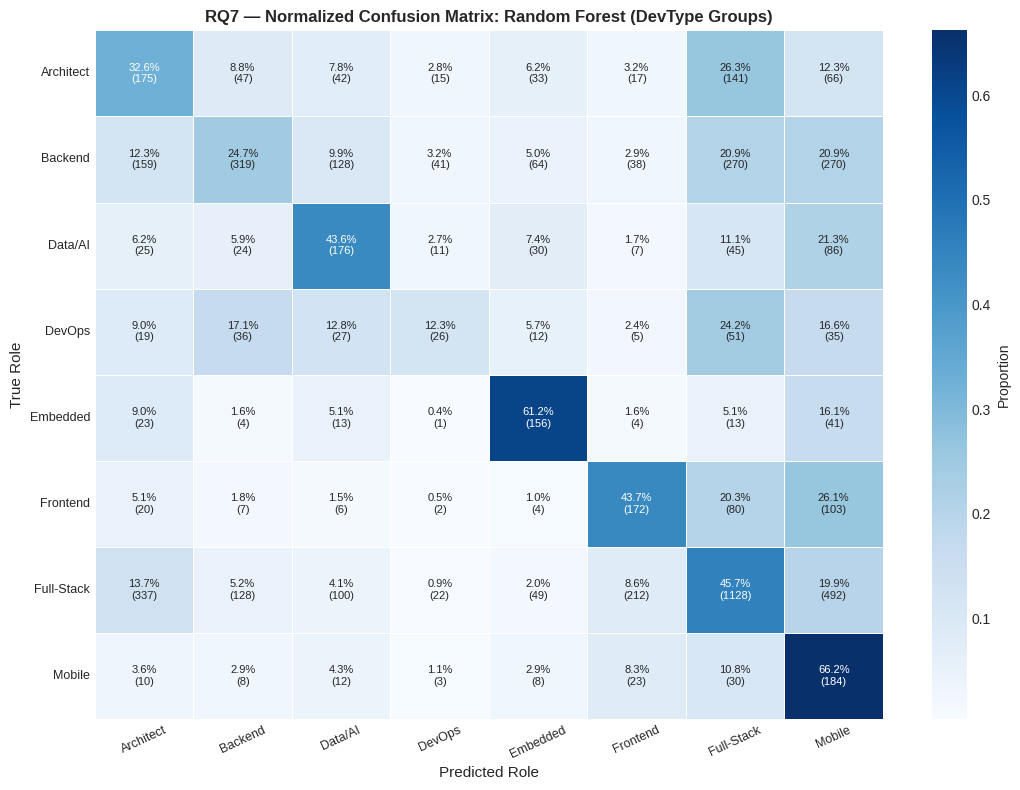

Saved figure: /kaggle/working/rq7_confusion_matrix_normalized.pdf


In [10]:
# Confusion matrix (normalized) for best model on Target B
best_b_name = results_b.loc[results_b['Macro_F1'].idxmax(), 'Model']
best_b_pipe = fitted_b[best_b_name]

y_b_pred = best_b_pipe.predict(X_b_te)
classes_b = sorted(y_b_te.unique())
cm_b = confusion_matrix(y_b_te, y_b_pred, labels=classes_b)
cm_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 8))
annot = np.empty(cm_b.shape, dtype=object)
for i in range(cm_b.shape[0]):
    for j in range(cm_b.shape[1]):
        annot[i, j] = f'{cm_norm[i,j]*100:.1f}%\n({cm_b[i,j]})'

sns.heatmap(cm_norm, ax=ax, annot=annot, fmt='', cmap='Blues',
            xticklabels=classes_b, yticklabels=classes_b,
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Predicted Role', fontsize=11)
ax.set_ylabel('True Role', fontsize=11)
ax.set_title(f'RQ7 — Normalized Confusion Matrix: {best_b_name} (DevType Groups)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=9, rotation=25)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
save_figure(fig, 'rq7_confusion_matrix_normalized.pdf')
plt.show()

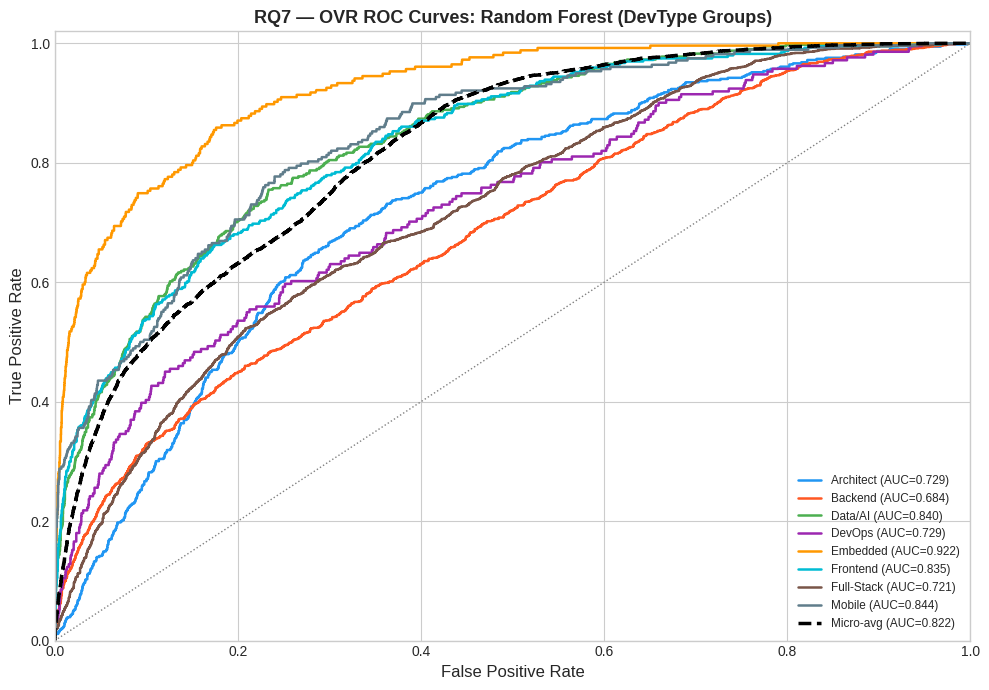

Saved figure: /kaggle/working/rq7_multiclass_roc_curves.pdf


In [11]:
from sklearn.metrics import roc_curve, auc

y_b_proba = best_b_pipe.predict_proba(X_b_te)
le = LabelEncoder().fit(classes_b)
y_b_te_enc = le.transform(y_b_te)

fig, ax = plt.subplots(figsize=(10, 7))

for i, cls in enumerate(classes_b):
    y_bin_cls = (y_b_te == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_bin_cls, y_b_proba[:, i])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.8, color=PALETTE[i % len(PALETTE)],
            label=f'{cls} (AUC={roc_auc_cls:.3f})')

# Micro-average
y_b_bin_all = label_binarize(y_b_te, classes=classes_b)
fpr_micro, tpr_micro, _ = roc_curve(y_b_bin_all.ravel(), y_b_proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, 'k--', linewidth=2.5, label=f'Micro-avg (AUC={auc_micro:.3f})')

ax.plot([0, 1], [0, 1], 'gray', linestyle=':', linewidth=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'RQ7 — OVR ROC Curves: {best_b_name} (DevType Groups)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
save_figure(fig, 'rq7_multiclass_roc_curves.pdf')
plt.show()

## 9. Summary Tables

In [12]:
all_results  = pd.concat([results_a, results_b],  ignore_index=True)
all_perclass = pd.concat([perclass_a, perclass_b], ignore_index=True)

save_table(all_results,  'rq7_model_comparison.csv')
save_table(all_perclass, 'rq7_per_class_metrics.csv')

print('Model Comparison:')
all_results

Saved table:  /kaggle/working/rq7_model_comparison.csv
Saved table:  /kaggle/working/rq7_per_class_metrics.csv
Model Comparison:


,Target,Model,Accuracy,Macro_F1,Weighted_F1,Kappa,OVR_AUC,CV_F1_Mean,CV_F1_Std,Train_Time_s
0,ICorPM,Logistic Regression,0.6285,0.5327,0.6819,0.1349,0.6571,0.5365,0.0040,5.65
1,ICorPM,Random Forest,0.7077,0.5578,0.7394,0.1355,0.6638,0.5601,0.0035,10.93
2,ICorPM,LightGBM,0.6151,0.5334,0.6711,0.1513,0.6880,0.5411,0.0065,3.31
3,DevType_Group,Logistic Regression,0.3364,0.3270,0.3489,0.2358,0.7927,0.3187,0.0079,33.96
4,DevType_Group,Random Forest,0.4003,0.3539,0.4189,0.2628,0.7882,0.3462,0.0069,10.95
5,DevType_Group,LightGBM,0.3729,0.3467,0.3890,0.2586,0.8013,0.3441,0.0060,16.28


## 10. Conclusions

In [13]:
best_a = results_a.loc[results_a['Macro_F1'].idxmax()]
best_b = results_b.loc[results_b['Macro_F1'].idxmax()]

print('=' * 60)
print('RQ7 CONCLUSION')
print('=' * 60)
print(f'Target A (ICorPM) — Best: {best_a["Model"]}')
print(f'  Macro-F1: {best_a["Macro_F1"]}  OVR-AUC: {best_a["OVR_AUC"]}  Kappa: {best_a["Kappa"]}')
print()
print(f'Target B (DevType Group) — Best: {best_b["Model"]}')
print(f'  Macro-F1: {best_b["Macro_F1"]}  OVR-AUC: {best_b["OVR_AUC"]}  Kappa: {best_b["Kappa"]}')
print()
print('Output files saved to /kaggle/working/:')
print('  rq7_role_distribution.pdf')
print('  rq7_confusion_matrix_normalized.pdf')
print('  rq7_multiclass_roc_curves.pdf')
print('  rq7_model_comparison.csv')
print('  rq7_per_class_metrics.csv')

RQ7 CONCLUSION
Target A (ICorPM) — Best: Random Forest
  Macro-F1: 0.5578  OVR-AUC: 0.6638  Kappa: 0.1355

Target B (DevType Group) — Best: Random Forest
  Macro-F1: 0.3539  OVR-AUC: 0.7882  Kappa: 0.2628

Output files saved to /kaggle/working/:
  rq7_role_distribution.pdf
  rq7_confusion_matrix_normalized.pdf
  rq7_multiclass_roc_curves.pdf
  rq7_model_comparison.csv
  rq7_per_class_metrics.csv
